In [8]:
import pandas as pd 
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv(r"C:/Users/User/Desktop/global_population_growth_2024.csv")

In [3]:
df.head()

,City,Country,Population_2023,Growth_Rate (%),Population_2024
0,Los Angeles,USA,26836512,1.308574,27187687
1,Shanghai,China,11673774,1.568945,11856929
2,Cairo,Egypt,22201723,4.871278,23283230
3,Mumbai,India,11440139,1.314396,11590507
4,Los Angeles,USA,3792427,4.344733,3957197


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City             1000 non-null   object 
 1   Country          1000 non-null   object 
 2   Population_2023  1000 non-null   int64  
 3   Growth_Rate (%)  1000 non-null   float64
 4   Population_2024  1000 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [16]:
df["Country"].unique()

array(['USA', 'China', 'Egypt', 'India', 'Australia', 'UK', 'Brazil',
       'Japan', 'Russia'], dtype=object)

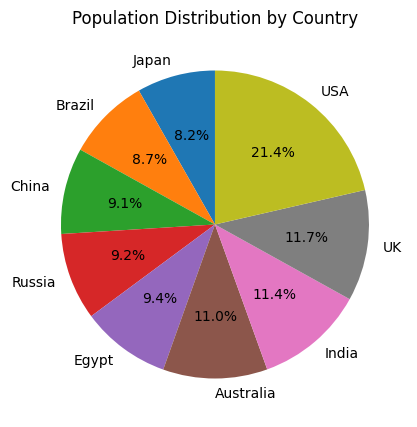

In [17]:
plt.figure(figsize=(5, 5))

country_population = df.groupby('Country')['Population_2023'].sum().sort_values() 

plt.pie(country_population, labels=country_population.index, autopct='%1.1f%%', startangle=90)
plt.title('Population Distribution by Country')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Los Angeles'),
  Text(1, 0, 'Shanghai'),
  Text(2, 0, 'Cairo'),
  Text(3, 0, 'Mumbai'),
  Text(4, 0, 'Sydney'),
  Text(5, 0, 'London'),
  Text(6, 0, 'Sao Paulo'),
  Text(7, 0, 'Tokyo'),
  Text(8, 0, 'New York'),
  Text(9, 0, 'Moscow')])

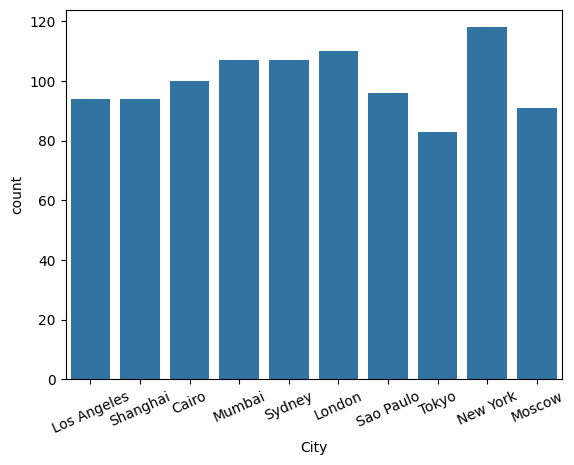

In [9]:
sns.countplot(x="City",data=df)
plt.xticks(rotation=24)

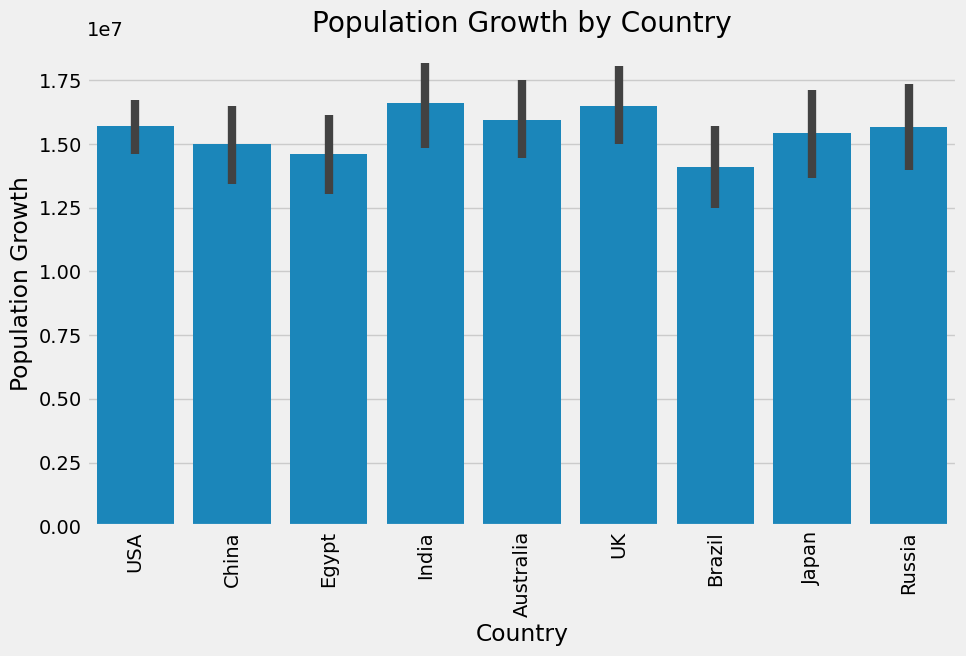

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Country",y="Population_2023",data=df)

plt.title('Population Growth by Country')
plt.xlabel('Country')
plt.ylabel('Population Growth')
plt.xticks(rotation=90)
plt.style.use('fivethirtyeight')
plt.show()

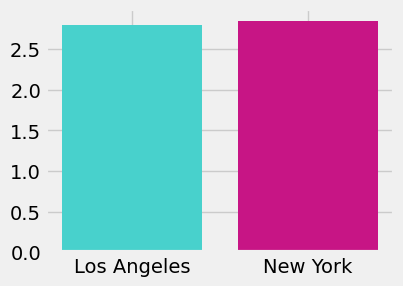

In [28]:
def cityGrowthBar(country):
    c=df[df['Country']==country]
    city=c.groupby(by='City').mean(numeric_only=True)
    plt.figure(figsize=(4, 3))
    plt.style.use('fast')
    plt.bar(city.index,city['Growth_Rate (%)'],color=['MediumTurquoise','MediumVioletRed'])
    plt.show()
cityGrowthBar('USA')

[I 2025-10-09 00:18:02,825] A new study created in memory with name: no-name-a6d390c6-d20c-4e1e-a843-7dcbbb4e560c


[I 2025-10-09 00:18:02,913] Trial 0 finished with value: 0.17364976946442812 and parameters: {'n_clusters': 4, 'init': 'k-means++'}. Best is trial 0 with value: 0.17364976946442812.


          City Country  Population_2023  Growth_Rate (%)  Population_2024
0  Los Angeles     USA         26836512         1.308574         27187687
1     Shanghai   China         11673774         1.568945         11856929
2        Cairo   Egypt         22201723         4.871278         23283230
3       Mumbai   India         11440139         1.314396         11590507
4  Los Angeles     USA          3792427         4.344733          3957197


[I 2025-10-09 00:18:03,143] Trial 1 finished with value: 0.14346204692408832 and parameters: {'n_clusters': 8, 'init': 'random'}. Best is trial 0 with value: 0.17364976946442812.
[I 2025-10-09 00:18:03,345] Trial 2 finished with value: 0.14012661577653002 and parameters: {'n_clusters': 6, 'init': 'random'}. Best is trial 0 with value: 0.17364976946442812.
[I 2025-10-09 00:18:03,421] Trial 3 finished with value: 0.139580299612443 and parameters: {'n_clusters': 6, 'init': 'k-means++'}. Best is trial 0 with value: 0.17364976946442812.
[I 2025-10-09 00:18:03,625] Trial 4 finished with value: 0.26292145377266174 and parameters: {'n_clusters': 2, 'init': 'random'}. Best is trial 4 with value: 0.26292145377266174.
[I 2025-10-09 00:18:03,699] Trial 5 finished with value: 0.1309502730435769 and parameters: {'n_clusters': 7, 'init': 'k-means++'}. Best is trial 4 with value: 0.26292145377266174.
[I 2025-10-09 00:18:03,768] Trial 6 finished with value: 0.1309502730435769 and parameters: {'n_cluste

estparm {'n_clusters': 2, 'init': 'random'}
 Silhouette score: 0.26292145377266174


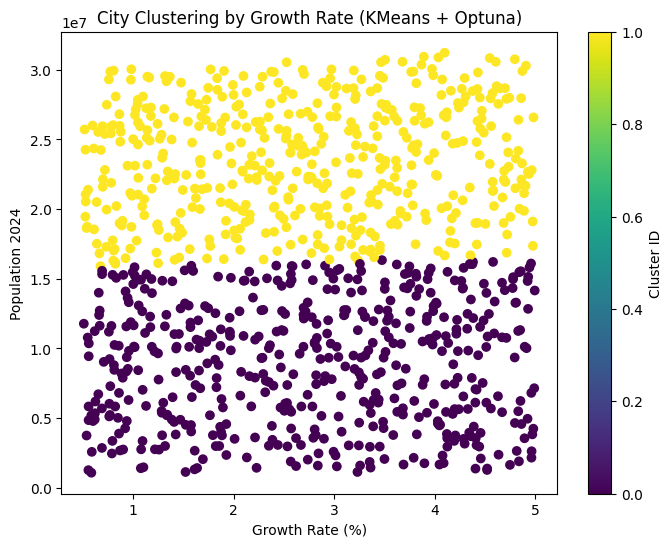

In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


df = pd.read_csv(r"C:/Users/User/Desktop/global_population_growth_2024.csv")

print(df.head())


numerical_cols = ['Population_2023', 'Growth_Rate (%)', 'Population_2024']
categorical_cols = ['Country',"City"]

X = df[numerical_cols + categorical_cols]


def objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 2, 8)
    init_method = trial.suggest_categorical('init', ['k-means++', 'random'])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(), categorical_cols)
        ]
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', KMeans(n_clusters=n_clusters, init=init_method, random_state=42))
    ])

    pipeline.fit(X)
    labels = pipeline['kmeans'].labels_
    score = silhouette_score(preprocessor.fit_transform(X), labels)
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\bestparm", study.best_params)
print(" Silhouette score:", study.best_value)


best_params = study.best_params

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(
        n_clusters=best_params['n_clusters'],
        init=best_params['init'],
        random_state=42
    ))
])

final_pipeline.fit(X)
df['Cluster'] = final_pipeline['kmeans'].labels_


final_score = silhouette_score(preprocessor.fit_transform(X), df['Cluster'])



fig = px.scatter(
    df,
    x='Growth_Rate (%)',
    y='Population_2024',
    color='Cluster',
    hover_data=['City', 'Country', 'Population_2023', 'Population_2024', 'Growth_Rate (%)'],
    title=" City Clustering by Population Growth (Interactive)",
    color_continuous_scale='Viridis'
)

fig.update_layout(
    xaxis_title="Growth Rate (%)",
    yaxis_title="Population 2024",
    title_x=0.5,
    title_font=dict(size=20)
)
fig.show()


plt.figure(figsize=(8,6))
plt.scatter(df['Growth_Rate (%)'], df['Population_2024'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Growth Rate (%)")
plt.ylabel("Population 2024")
plt.title("City Clustering by Growth Rate (KMeans + Optuna)")
plt.colorbar(label='Cluster ID')
plt.show()

In [ ]:
d